### Tests

In [1]:
import pandas as pd

In [2]:
from baseline_electricity_model import build_calendar_features, load_data

CONSO_PATH = "base_data/EU/conso_EU_daily.csv"
TEMP_PATH = "base_data/temp_era/temp_EU_daily_era.csv"
conso, temp = load_data(CONSO_PATH, TEMP_PATH)
temp = temp.drop(columns= ["FR"])
calendar_df = build_calendar_features(conso.index)
#calendar_df

[load_data] Période retenue : 2016-01-01 → 2025-12-31
[load_data] Régions : ['BE', 'CH', 'DE', 'ES', 'IT', 'UK', 'IE', 'NL', 'PT']
[load_data] N jours : 2922


## Pays européens

In [3]:
from baseline_electricity_model import get_european_public_holidays, build_calendar_features_EU, run_pipeline_EU, run_pipeline, predict_demand, plot_predictions_vs_actual, get_school_holidays

#### Test pipeline de base avec données françaises

In [4]:
models, baselines, calendar_df = run_pipeline(CONSO_PATH, TEMP_PATH)

[load_data] Période retenue : 2016-01-01 → 2025-09-30
[load_data] Régions : ['BE', 'CH', 'DE', 'ES', 'IT', 'UK', 'IE', 'NL', 'PT']
[load_data] N jours : 2830

[calendar] Génération des variables calendaires...
[calendar] 24 variables générées

=== ESTIMATION OLS PAR RÉGION ===

Région                                  R²  R²adj     RMSE   Tc1   Tc2     N
---------------------------------------------------------------------------
  BE                                 0.866  0.864    376.6  14.0  18.0  2622
  CH                                 0.766  0.764    410.9  13.0  20.5  2622
  DE                                 0.863  0.862   2593.8  15.0  18.0  2622
  ES                                 0.851  0.849   1151.2  15.0  20.0  2622
  IT                                 0.805  0.803   2365.2  11.5  19.5  2622
  UK                                 0.901  0.900   1527.7  13.0  16.5  2622
  IE                                 0.871  0.870    153.2  10.0  16.0  2622
  NL                         

#### Test amélioré pipeline EU

Jours fériés spécifiques par pays, pas de période de vacances retenues sauf Noël et Août, températures lissées pour l'inertie du batiment en hiver.

In [4]:
training_period = list(range(2017,2025))

In [5]:
models, baselines, calendar_df = run_pipeline_EU(CONSO_PATH, TEMP_PATH, training_period = training_period)

[load_data] Période retenue : 2017-01-01 → 2024-12-31
[load_data] Régions : ['BE', 'CH', 'DE', 'ES', 'IT', 'UK', 'IE', 'NL', 'PT']
[load_data] N jours : 2191

[calendar] Génération des variables calendaires EU...
[calendar] 21 variables par pays

=== ESTIMATION OLS PAR PAYS ===

  Température HDD  : T_eff(alpha=0.7)
  Température CDD  : T_cdd(alpha=1)
  Années exclues   : [2020, 2021]

Pays           R²  R²adj     RMSE   Tc1   Tc2     N
-------------------------------------------------------
  BE        0.894  0.893    335.4  13.5  17.0  1984
  CH        0.797  0.795    386.7  11.0  20.5  1984
  DE        0.909  0.908   2111.1  14.5  18.0  1984
  ES        0.922  0.922    842.9  14.5  20.0  1984
  IT        0.879  0.878   1873.1  13.0  19.0  1984
  UK        0.933  0.932   1203.3  13.0  16.5  1984
  IE        0.923  0.922    111.7  12.0  16.0  1984
  NL        0.781  0.778    606.1  13.0  16.0  1984
  PT        0.871  0.869    217.2  15.0  18.5  1984

[diag] Réponses f(T) par pays...
[

In [10]:
import numpy as np
_, useless = get_school_holidays(list(range(2010, 2027)))
alphas = np.arange(0,1.1,0.1)
alphas

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [9]:
temp.columns

Index(['DE', 'ES', 'BE', 'CH', 'UK', 'NL', 'IE', 'PT', 'IT'], dtype='object')

In [ ]:
for alpha in alphas :
    models, baselines, calendar_df = run_pipeline_EU(CONSO_PATH, TEMP_PATH, training_period = training_period, )
    for c in temp.columns:
        res = predict_demand(models[c], c, useless, temp[c].loc["2016"], False)["y_pred"] - conso[c].loc["2016"]
        error[alpha][c] = (res*res).sum()

(res*res).sum()

1204071959.0716393

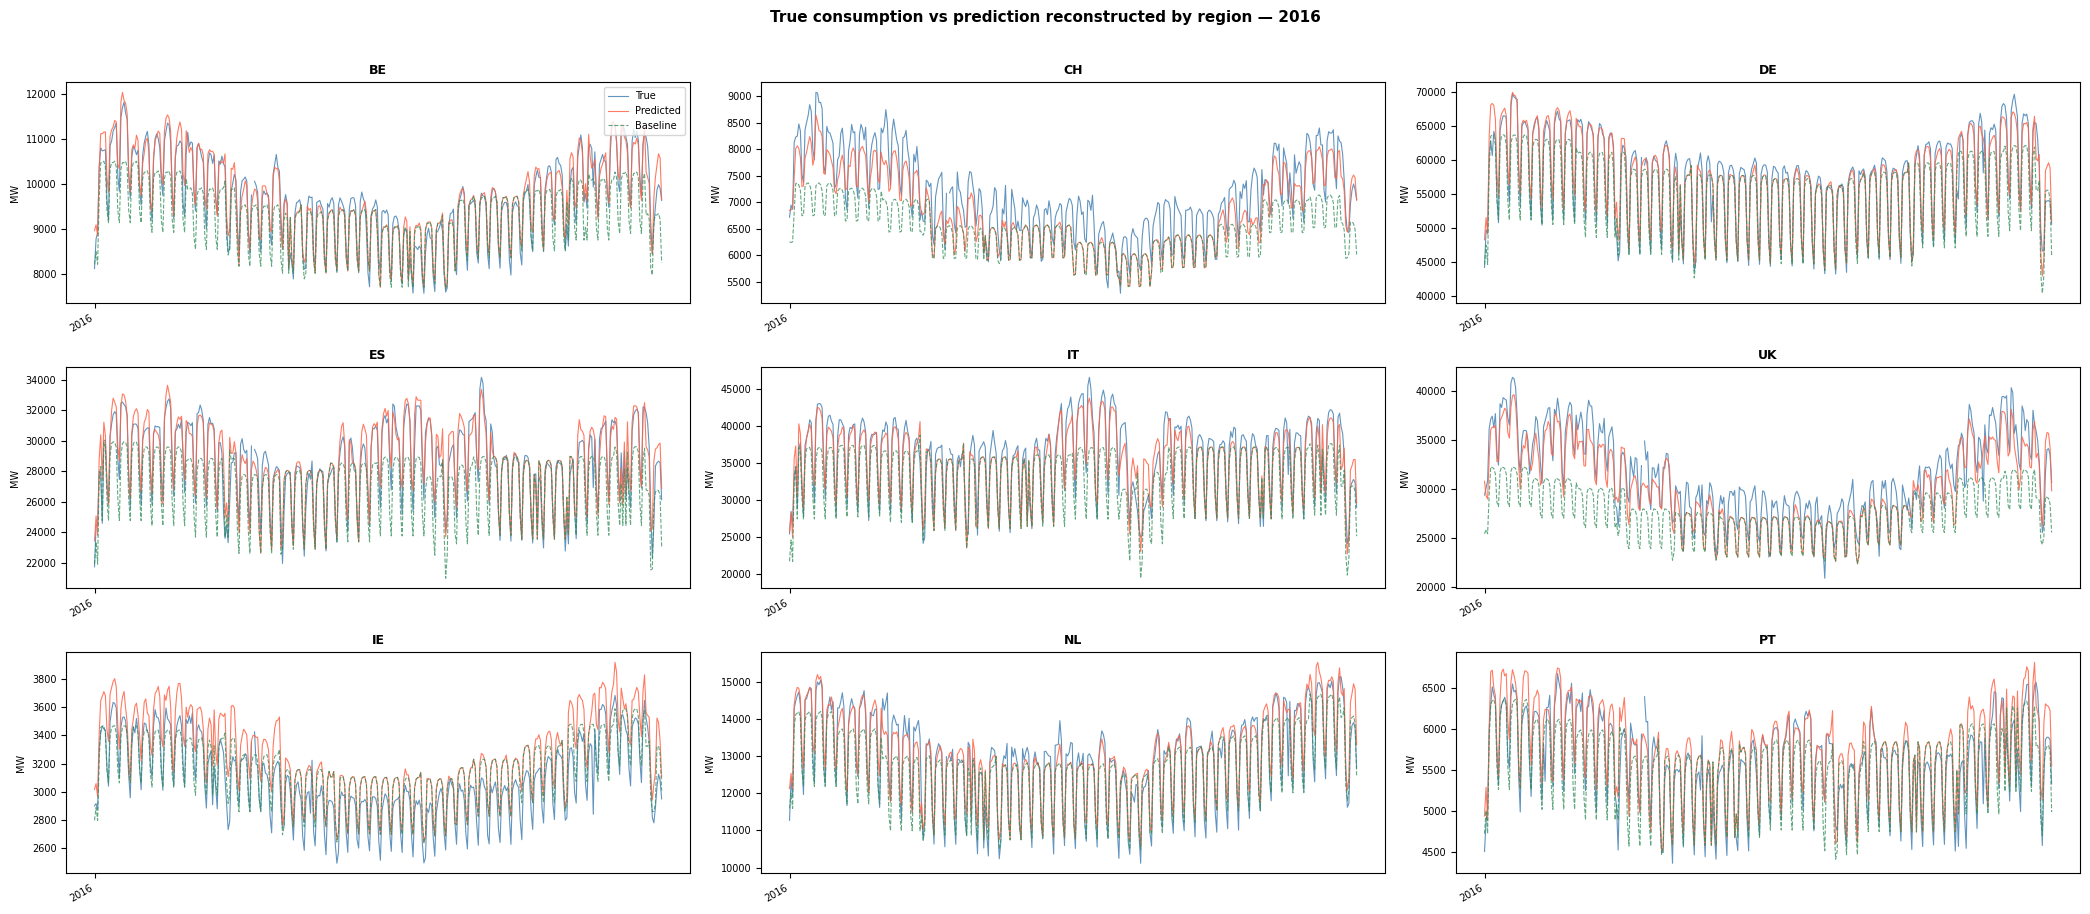

In [ ]:
plot_predictions_vs_actual(models, conso, temp, useless, 2016, is_France = False)

#### Exploitation résultats Espagne

In [13]:
predict_demand(models["ES"], "ES", useless, temp["ES"], False)#["y_temp"].sum()/1e6*24/10

,y_pred,y_base,y_temp,HDD,CDD
2016-01-01,23437.682921,21916.416614,1521.266307,3.697712,0.0
2016-01-02,25072.231925,23368.959222,1703.272703,4.140112,0.0
2016-01-03,23808.399337,21916.416614,1891.982723,4.598806,0.0
2016-01-04,28806.376023,27621.329332,1185.046691,2.880470,0.0
2016-01-05,30384.213245,28305.718080,2078.495165,5.052158,0.0
...,...,...,...,...,...
2025-12-27,23882.145108,20772.963610,3109.181498,7.557427,0.0
2025-12-28,21995.214869,19320.421002,2674.793867,6.501570,0.0
2025-12-29,26372.336928,23572.791113,2799.545815,6.804802,0.0
2025-12-30,27498.291157,24368.099603,3130.191554,7.608496,0.0


In [ ]:
def calcul_demande_moyenne_thermosensible(models, reg, useless, temp, nb_years = 10):
    HDD_tot = predict_demand(models[reg], reg, useless, temp[reg], False)["HDD"].sum()
    CDD_tot = predict_demand(models[reg], reg, useless, temp[reg], False)["CDD"].sum()

    cool_rate = models[reg]["results"].params["CDD"]
    heat_rate = models[reg]["results"].params["HDD"]

    cool_demand = cool_rate*CDD_tot/1e6*24/nb_years 
    heat_demand = heat_rate*HDD_tot/1e6*24/nb_years

    print(f"Demande thermosensible moyenne en {reg}:")
    print(f"heating: {heat_demand:.2f} TWh/an, cooling: {cool_demand:.2f} TWh/an")


In [13]:
calcul_demande_moyenne_thermosensible(models, "ES", useless, temp)

Demande thermosensible moyenne en ES:
heating: 7.06 TWh/an, cooling: 6.11 TWh/an


In [14]:
calcul_demande_moyenne_thermosensible(models, "DE", useless, temp)

Demande thermosensible moyenne en DE:
heating: 11.76 TWh/an, cooling: 0.83 TWh/an


In [15]:
calcul_demande_moyenne_thermosensible(models, "IT", useless, temp)

Demande thermosensible moyenne en IT:
heating: 6.02 TWh/an, cooling: 9.52 TWh/an


In [16]:
calcul_demande_moyenne_thermosensible(models, "UK", useless, temp)

Demande thermosensible moyenne en UK:
heating: 14.75 TWh/an, cooling: 0.28 TWh/an


#### Seuils et pente de chauffage/refroidissement pour les pays frontaliers

In [14]:
temp.columns

Index(['DE', 'ES', 'BE', 'CH', 'UK', 'NL', 'IE', 'PT', 'IT'], dtype='object')

In [29]:
df_thresh_n_rates = pd.DataFrame(index = temp.columns)
df_thresh_n_rates["heating_rate"] = 0
df_thresh_n_rates["heating_threshold"] = 0
df_thresh_n_rates["cooling_rate"] = 0
df_thresh_n_rates["cooling_threshold"] = 0
for r in df_thresh_n_rates.index:
    df_thresh_n_rates["heating_rate"].loc[r] = models[r]["results"].params["HDD"]
    df_thresh_n_rates["cooling_rate"].loc[r] = models[r]["results"].params["CDD"]
    df_thresh_n_rates["heating_threshold"].loc[r] = models[r]["T_c1"]
    df_thresh_n_rates["cooling_threshold"].loc[r] = models[r]["T_c2"]

df_thresh_n_rates.to_csv("elec_thermo_parameters_EU.csv")

#### Extraction des baselines

In [30]:
df_base = pd.DataFrame()
for c in conso.columns:
    df_base[c] = predict_demand(models[c], c, useless, temp[c], False)["y_base"]

<Axes: >

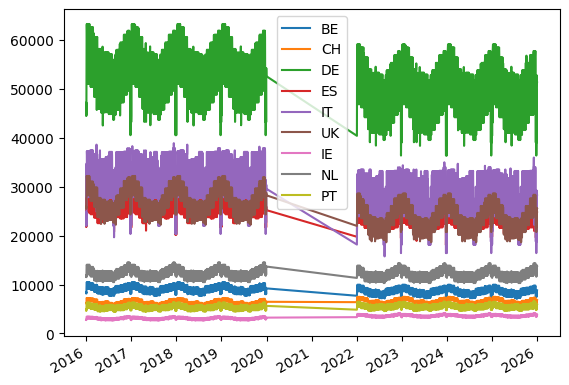

In [31]:
df_base.plot()

In [32]:
df_base.to_csv("baseline_noT_EU.csv")

In [23]:
df_base[(df_base.index < "2023") & (df_base.index >= "2022")]

,BE,CH,DE,ES,IT,UK,IE,NL,PT
2022-01-01,7676.665048,6449.826159,40442.787910,19633.188599,17828.691778,21881.791334,3291.732095,11193.269789,4806.685614
2022-01-02,7676.665048,6449.826159,40442.787910,19633.188599,17828.691778,21881.791334,3291.732095,11193.269789,4806.685614
2022-01-03,8873.864839,7001.141704,51739.375995,23885.558709,25716.105916,25461.362524,3623.660110,12985.482248,5663.838687
2022-01-04,9019.387105,7043.961849,52755.716176,24680.867199,27312.127406,25939.050088,3684.406694,13135.956929,5847.672063
2022-01-05,9943.425961,7559.949295,59515.821174,26136.266176,30856.998553,28630.957135,3961.655614,13767.722469,6429.526867
...,...,...,...,...,...,...,...,...,...
2022-12-27,8778.961387,6816.901687,51185.746169,24368.099603,27829.075796,25646.915824,3412.989273,13603.218780,5825.283322
2022-12-28,8775.878689,6829.424050,51397.381913,24481.875715,28016.514641,25575.400598,3816.959010,13643.894004,5868.775568
2022-12-29,8808.149363,6790.108574,51321.909524,24449.555093,28021.806674,25485.153423,3818.372502,13684.434922,5883.958510
2022-12-30,8681.095753,6682.047495,49903.213613,24119.096797,27287.204149,24899.295954,3854.720435,13493.415406,5800.923528
